# BikeZ-ETH Dataset Tutorial

This notebook walks through the core BikeZ-ETH pipeline: loading a subsampled bike trajectory dataset, loading the site's road geometry registries, and visualizing transformed trajectories into road-aligned (s, d) coordinates.

**Contents:**
1. Load trajectory data and site geometry for a given location/timeslot
2. Visualize the site's road network, bike lanes, and turn geometry
3. Inspect how multiple bikes move through a single lane segment
4. Follow one bike's full path, in both `(x, y)` and `(s, d)`, as it crosses segments

**Prerequisites:** see the main `README.md` for dataset setup (`BikeZ_Config.data_root`, `BikeZ_Config.subsampled_data_root`) and the `registry_location{loc_num}.pkl` files this notebook expects under `../data/`. Run this notebook from the `src/` directory so relative imports and local modules resolve correctly. Ensure a `../maps/` output directory exists before running.

**Minimal environment requirements:** Install needed: `pandas`, `numpy`, `scipy`, `shapely`, `matplotlib`, `plotly`, `pyproj`, `folium`, `pytz`. No install needed (`stdlib`): `pickle`, `os`, `webbrowser`, `logging`.

In [14]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Dataset Configuration

Pick a date, intersection, code, and timeslot from the summary table in `README.md`. Location number `loc_num`, and the `XY_2056_Bounds` and offsets are looked up automatically.

In [15]:
from _constants import BikeZ_Config

BikeZ_Config = BikeZ_Config()
subsampled_data_root = BikeZ_Config.subsampled_data_root

date      = "2025-09-30"
mode      = "bike"
timeslot  = "PM1"
loc_num   = 13

intersection, code = BikeZ_Config.get_intersection_code(date, loc_num, timeslot)
print(f"Intersection: {intersection}, Code: {code}")
XY_2056_Bounds = BikeZ_Config.XY_2056_Bounds[date][(intersection, code)]
X_2056_offset = XY_2056_Bounds[0][0]
Y_2056_offset = XY_2056_Bounds[1][0]

Intersection: D2, Code: I


## Import Trajectory Data + Site Geometry Configuration

Trajectory data and the site's geometry registries are stored separately. The registry is always stored in `../data/` folder.

In [16]:
# Load Trajectories
filename = f"location_{loc_num}/{loc_num}_{mode}s_{date}_{timeslot}_lane.csv"
df = pd.read_csv(subsampled_data_root + filename)
df.columns

Index(['veh_id', 'veh_type', 'datetime', 'time', 'x_act_ekf', 'y_act_ekf',
       'x_ekf', 'y_ekf', 'lon_ekf', 'lat_ekf', 'speed_ekf', 'a_ekf',
       'angle_ekf', 'angular_vel_ekf', 'in_gap', 'off_grid', 's_native',
       'd_native', 's_dot', 'd_dot', 's_ddot', 'd_ddot', 'd_to_bike_boundary',
       'movement_key', 'segment_id', 'segment_type', 'segment_role',
       'match_quality', 'in_bike_lane', 'is_fallback', 'is_reverse',
       'car_lane_idx'],
      dtype='object')

- (`x_act_ekf`, `y_act_ekf`) are the x, y *global* coordinates in EPSG:2056 system.
- (`x_ekf`, `y_ekf`) are the x, y *local* coordinates; where `x_ekf = x_act_ekf - X_2056_offset` and `y_ekf = y_act_ekf - Y_2056_offset`. This is for numerical stability.

See the `README.md` column reference for the rest of columns.

In [17]:
# Load geometry, segment, and movement registries
registry_path = f'../data/registry_location{loc_num}.pkl'
registry = pickle.load(open(registry_path, 'rb'))
geometry_store    = registry['geometry_store']
segment_registry  = registry['segment_registry']
movement_registry = registry['movement_registry']
max_chain_length  = registry['metadata'].get('max_chain_length', 3)


These dict registries act as the static layer defining the site geometry and infrastructure.
- **`geometry_store`**: one entry per physical road axis --> the B-spline fit to its centerline, arc length, stop/yield lines.
- **`segment_registry`**: one entry per *directed* travel segment (a lane or a turn), e.g. `FlurstrS_NB` or `turn_FlurstrS_NB_2_FlurstrN_NB`. Also, it stores bike lane information (e.g. boundaries and width)
- **`movement_registry`**: one entry per full movement through the intersection --> an ordered chain of segments a bike travels along (approach → turn → departure).

## Visualize Site Geometry Configuration

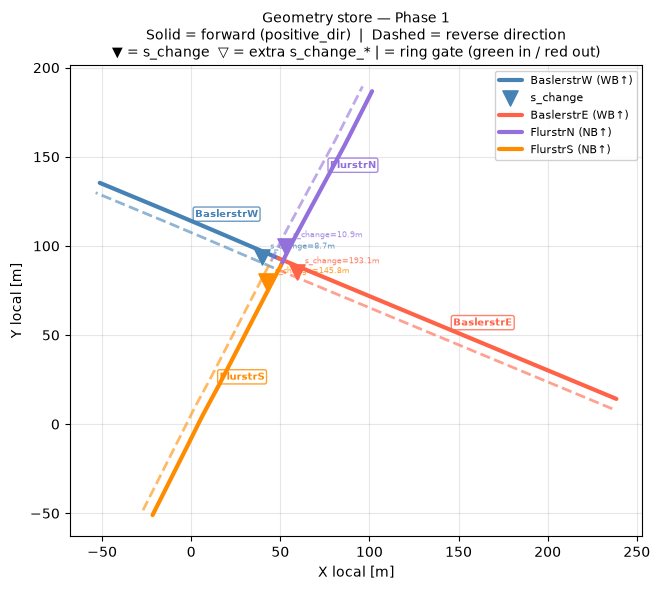

In [18]:
from tools_plot_registry import plot_geometry_store

plot_geometry_store(geometry_store, offset_m=3.0, figuresize=(8, 6))

- `geometry_store` contains the four road links forming the on-hand intersection: `BaslerstrW`, `BaslerstrE`, `FlurstrS`, and `FlurstrN`.
- For each link or dict entry, it stores the B-spline parameters for its centerline.
- For each link or dict entry, it stores `s_stop`, `s_yield`, and `s_change` which denote the longitudinal position at the stop line, yield line and change point respectively. The change point is where the trajectory hands off from this segment to the next one.
- For each link or dict entry, it stores the `positive_dir` which denotes which travel direction is the spline positive direction. This is denoted in the figure legend. For instance, `BaslerstrW` has a positive direction of *westbound* (i.e. `WB`).

The next cell opens the interactive HTML map (road centerlines, bike lane bands, validity polygons) in your default browser. Skip this cell if running the notebook remotely / headless.

In [ ]:

# registry_map_path = f'../maps/registry_{date}_{intersection}_{code}.html'      # a swisstopo base-image
registry_map_path = f'../maps/registry_location{loc_num}.html'                   # a GIS-ZH base-image

import os
import webbrowser

full_path = os.path.abspath(registry_map_path)
webbrowser.open(f'file://{full_path}')

True

In [20]:
from tools_plot_registry import plot_segment_registry_plotly

plot_segment_registry_plotly(
    geometry_store, segment_registry,
    offset_m=0, turn_offset_m=0, show_validity_polygons=True,
    width=1000, height=600
)

- `segment_registry` contains all *travel-directed* segments information (e.g. `BaslerstrW_WB` and `BaslerstrW_EB`).
- `segment_registry` contains turning segments inside the intersection area. `turn_BaslerstrW_EB_2_FlurstrS_SB` denotes the turning centerline from `BaslerstrW_EB` (i.e. *approach* segment) to `FlurstrS_SB` (i.e. *departure* segment).
- For each segment entry, `validity_polygon` is available to represent the road physical space attributed to this segment.
- For each segment entry, `bike_lane` defines the attributes of the bike lane (e.g. its boundary with respect to centerline spline, its width, if it is dedicated for bikes only).

## Visualize All Trajectories on an Approach Lane Segment

Before following a single bike, look at every bike that passed through one segment (e.g. `BaslerstrW_EB`). This reveals whether stop-line and yield-line positions look right relative to where bikes actually slow down.

[Text(0.5, 0, 'Time (s)'), Text(0, 0.5, 's_native (m)')]

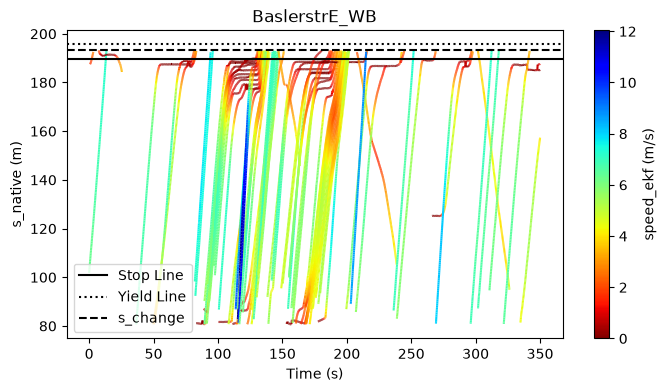

In [21]:
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

seg_key = 'BaslerstrE_WB'
seg_df = df[df['segment_id'] == seg_key].copy()
seg_df = seg_df[seg_df['time'] <= 350]
geom_key = segment_registry[seg_key]['geometry_key']
s_stop = geometry_store[geom_key]['s_stop']
s_yield = geometry_store[geom_key]['s_yield']
s_change = geometry_store[geom_key]['s_change']
ax.axhline(y=s_stop, label='Stop Line', color='black', linestyle='solid', zorder=5)
ax.axhline(y=s_yield, label='Yield Line', color='black', linestyle='dotted', zorder=5)
ax.axhline(y=s_change, label='s_change', color='black', linestyle='dashed', zorder=5)
ax.legend()
norm = Normalize(vmin=0, vmax=seg_df['speed_ekf'].max())
for veh_id, veh_df in seg_df.groupby('veh_id'):
    veh_df = veh_df.sort_values('time')
    x = veh_df['time'].to_numpy()
    y = veh_df['s_native'].to_numpy()
    c = veh_df['speed_ekf'].to_numpy()
    # Create line segments
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(
        segments, cmap='jet_r', norm=norm
    )
    # Color each segment by the average speed of its endpoints
    lc.set_array((c[:-1] + c[1:]) / 2)
    lc.set_linewidth(1.5)
    ax.add_collection(lc)
ax.autoscale()
cbar = plt.colorbar(lc, ax=ax)
cbar.set_label('speed_ekf (m/s)')
ax.set_title(seg_key)
ax.set(xlabel='Time (s)', ylabel='s_native (m)')

You can observe queuing behavior, as well as the signal cycles (evidenced by the batches/waves of bikes stopping and then moving).

## Visualize Single Bicycle Trajectory

Now zoom into one bike. Bicycle with `veh_id = 359` is picked arbitrarily here (biased by segment coverage). Swap it for any `veh_id` present in the movement of interest to inspect a different trajectory.

In [22]:
movement_key = 'BaslerstrW_EB_2_FlurstrN_NB'

# Pick a bike at random biased by most segments traversed
sub_df = df[df["movement_key"] == movement_key]
sub_df = sub_df.groupby("veh_id").filter(
    lambda x: x["segment_id"].nunique() >= 2
)
unique_bikes = sub_df["veh_id"].unique()
counts_series = sub_df["veh_id"].value_counts()
counts = counts_series.values
probabilities = counts / counts.sum()
bike_id = 359 #np.random.choice(unique_bikes, p=probabilities)
bike_df = df[df['veh_id'] == bike_id].copy()

In [23]:
# Compute travel-directed s, d
from tools_lane_coords_V5 import compute_travel_directed_s_d

bike_df = compute_travel_directed_s_d(bike_df, segment_registry, geometry_store)
# Adds 's', 'd', 'cumulative_s' columns to bike_df
bike_df.columns

Index(['veh_id', 'veh_type', 'datetime', 'time', 'x_act_ekf', 'y_act_ekf',
       'x_ekf', 'y_ekf', 'lon_ekf', 'lat_ekf', 'speed_ekf', 'a_ekf',
       'angle_ekf', 'angular_vel_ekf', 'in_gap', 'off_grid', 's_native',
       'd_native', 's_dot', 'd_dot', 's_ddot', 'd_ddot', 'd_to_bike_boundary',
       'movement_key', 'segment_id', 'segment_type', 'segment_role',
       'match_quality', 'in_bike_lane', 'is_fallback', 'is_reverse',
       'car_lane_idx', 's', 'd', 'cumulative_s'],
      dtype='object')

- **`(s_native, d_native)`**: position along/across the *native segment's* spline. **Invertible** back to (x, y) given `segment_id`.
- **`(s, d)`**: the *travel-directed* version (sign-flipped for `is_reverse` bikes, or travel directions opposite to native positive direction according to `is_forward`).
- **`cumulative_s`**: stitched across the full movement chain, so a bike's path is monotonically increasing even as it crosses segment boundaries.

### Plot A: XY path over site geometry

Overlays the bike's raw trajectory on road centerlines, bike lane bands, and the turn it took, in real-world (x, y) coordinates.

In [24]:
import plotly.graph_objects as go
from tools_utils import add_road_axes_plotly, add_bike_lane_boundaries_plotly, add_turn_centerline_plotly

turn_keys = [f'turn_{movement_key}']
fig = go.Figure()

fig, geom_color_map = add_road_axes_plotly(fig, geometry_store, offset_m=0, alpha=0.4)
fig = add_bike_lane_boundaries_plotly(fig, geometry_store, segment_registry, alpha=0.4)
fig, turn_colors = add_turn_centerline_plotly(
    fig, geometry_store, segment_registry, turn_keys=turn_keys, alpha=0.4, show_validity_polygons=False
)

for key, grp in bike_df.groupby('segment_id'):
    grp = grp.sort_values('time')
    geom_key = key.split('_')[0]
    if geom_key in geom_color_map:
        col = geom_color_map[geom_key]
    elif key in turn_colors:
        col = turn_colors[key]
    else:
        col = 'gray'  # Default color if no match found
    fig.add_trace(go.Scatter(
        x=grp['x_ekf'], y=grp['y_ekf'],
        mode='lines+markers',
        name=f'Bike Trajectory ({key})',
        marker=dict(size=4, color=col),
        line=dict(width=2.5, color=col),
        hovertemplate=(
            f'segment_id={key}<br>'
            'time=%{customdata[0]:.2f}<br>'
            'x=%{x:.2f}, y=%{y:.2f}<br>'
            's_native=%{customdata[1]:.2f}, d_native=%{customdata[2]:.2f}<extra></extra>'
        ),
        customdata=grp[['time', 's_native', 'd_native']].values,
    ))

fig.update_layout(
    title=f'Bike ID {bike_id}:  XY path over site geometry',
    xaxis_title='X local (m)', yaxis_title='Y local (m)',
    template='plotly_white',
    xaxis=dict(range=[XY_2056_Bounds[0][0]-X_2056_offset, XY_2056_Bounds[0][1]-X_2056_offset]),
    yaxis=dict(scaleanchor='x', scaleratio=1, range=[XY_2056_Bounds[1][0]-Y_2056_offset, XY_2056_Bounds[1][1]-Y_2056_offset]),
    legend=dict(groupclick='togglegroup'),
    width=1000, height=600,
)
fig

### Plot B: cumulative_s vs d

The same trajectory in road-aligned coordinates, stitched across segment boundaries. A straight-ish horizontal line means the bike stayed centered in its lane; deviations in `d` show lateral drift. Green shading marks `in_bike_lane == 1` regions.

In [25]:
fig = go.Figure()

for key, grp in bike_df.groupby('segment_id'):
    grp = grp.sort_values('time')
    geom_key = key.split('_')[0]
    if geom_key in geom_color_map:
        col = geom_color_map[geom_key]
    elif key in turn_colors:
        col = turn_colors[key]
    else:
        col = 'gray'  # Default color if no match found
    fig.add_trace(go.Scatter(
        x=grp['cumulative_s'], y=grp['d'],
        mode='lines+markers',
        name=str(key),
        marker=dict(size=5, color=col),
        line=dict(width=1.5),
        hovertemplate=(
            f'segment_id={key}<br>'
            'time=%{customdata[0]:.2f}<br>'
            'x=%{x:.2f}, y=%{y:.2f}<br>'
            's_native=%{customdata[1]:.2f}, d_native=%{customdata[2]:.2f}<extra></extra>'
        ),
        customdata=grp[['time', 's_native', 'd_native']].values,
    ))

# --- highlight in_bike_lane == True regions ---------------------------
in_lane = (bike_df['in_bike_lane'] == 1)
block_id = (in_lane != in_lane.shift()).cumsum()

lane_blocks = (
    bike_df[in_lane]
    .groupby(block_id[in_lane])['cumulative_s']
    .agg(s_min='min', s_max='max')
)

for _, row in lane_blocks.iterrows():
    fig.add_vrect(
        x0=row['s_min'], x1=row['s_max'],
        fillcolor='seagreen', opacity=0.12,
        line_width=0,
        layer='below',   # keep it behind the trace lines/markers
    )

# dummy trace so the shading gets a legend entry (vrect has no legend of its own)
fig.add_trace(go.Scatter(
    x=[None], y=[None], mode='markers',
    marker=dict(size=10, color='mediumseagreen', opacity=0.4, symbol='square'),
    name='in_bike_lane',
    showlegend=True,
))

fig.add_hline(y=0, line=dict(color='gray', width=1, dash='dot'))

fig.update_layout(
    title=f'Bike ID {bike_id}:  cumulative_s vs d',
    xaxis_title='cumulative_s (m)',
    yaxis_title='d (m, lateral offset)',
    template='plotly_white',
    legend_title='segment_id',
    legend=dict(groupclick='togglegroup'),
    width=800, height=400,
)
fig

### Plot C: per-segment breakdown (s_native / d_native and time)

Facets the trajectory by `segment_id`. Top row shows the path shape per segment; bottom row shows how quickly the bike moved through each. Circle/diamond markers denote the start/end of each segment to indicate direction of travel.

In [26]:
from plotly.subplots import make_subplots

segments = list(bike_df['segment_id'].unique())
n = len(segments)

def _subplot_title(seg_key, grp):
    is_rev = grp['is_reverse'].iloc[0] if 'is_reverse' in grp else 'NA'
    seg_entry = segment_registry.get(seg_key, {})
    is_fwd = seg_entry.get('is_forward', 'NA')
    return f'{seg_key}<br>is_reverse={is_rev}, is_forward={is_fwd}'

# subplot_titles is filled row-major: all of row 1, then all of row 2
row1_titles = [
    _subplot_title(seg, bike_df[bike_df['segment_id'] == seg])
    for seg in segments
]
row2_titles = ['time vs s_native'] * n

fig = make_subplots(
    rows=2, cols=n,
    subplot_titles=row1_titles + row2_titles,
    shared_yaxes=True,          # applies within each row independently
    horizontal_spacing=0.03,
    vertical_spacing=0.12,
    row_heights=[0.6, 0.4],
)
fig.update_annotations(font_size=12)

for i, key in enumerate(segments, start=1):
    grp = bike_df[bike_df['segment_id'] == key].sort_values('time')

    geom_key = key.split('_')[0]
    if geom_key in geom_color_map:
        col = geom_color_map[geom_key]
    elif key in turn_colors:
        col = turn_colors[key]
    else:
        col = 'gray'

    # --- in_bike_lane contiguous blocks, within this segment's rows ----
    in_lane = (grp['in_bike_lane'] == 1)
    block_id = (in_lane != in_lane.shift()).cumsum()
    lane_blocks = (
        grp[in_lane]
        .groupby(block_id[in_lane])
        .agg(s_min=('s_native', 'min'), s_max=('s_native', 'max'),
             t_min=('time', 'min'), t_max=('time', 'max'))
    )

    # --- row 1: s_native vs d_native (line) --------------------------
    for _, row in lane_blocks.iterrows():
        fig.add_vrect(
            x0=row['s_min'], x1=row['s_max'],
            fillcolor='seagreen', opacity=0.12,
            line_width=0, layer='below',
            row=1, col=i,
        )
    fig.add_trace(
        go.Scatter(
            x=grp['s_native'], y=grp['d_native'],
            mode='lines',
            name=str(key),
            line=dict(width=1.5, color=col),
            showlegend=False,
            hovertemplate=(
                f'segment_id={key}<br>'
                's_native=%{x:.2f}, d_native=%{y:.2f}<br>'
                'time=%{customdata:.2f}<extra></extra>'
            ),
            customdata=grp['time'],
        ),
        row=1, col=i,
    )

    # start / end markers, to show direction
    ends = grp.iloc[[0, -1]]
    fig.add_trace(
        go.Scatter(
            x=ends['s_native'], y=ends['d_native'],
            mode='markers',
            marker=dict(
                size=[9, 11],
                color=col,
                symbol=['circle', 'diamond'],
                line=dict(color='black', width=0.5),
            ),
            name=str(key),
            showlegend=False,
            hovertemplate=(
                f'segment_id={key}<br>'
                '%{text}<br>'
                's_native=%{x:.2f}, d_native=%{y:.2f}<br>'
                'time=%{customdata:.2f}<extra></extra>'
            ),
            text=['start', 'end'],
            customdata=ends['time'],
        ),
        row=1, col=i,
    )

    fig.add_hline(y=0, line=dict(color='gray', width=1, dash='dot'),
                  row=1, col=i)

    fig.update_xaxes(title_text='s_native (m)', row=1, col=i)
    if i == 1:
        fig.update_yaxes(title_text='d_native (m)', row=1, col=i)

    # --- row 2: time vs s_native (line) -------------------------------
    for _, row in lane_blocks.iterrows():
        fig.add_vrect(
            x0=row['t_min'], x1=row['t_max'],
            fillcolor='seagreen', opacity=0.12,
            line_width=0, layer='below',
            row=2, col=i,
        )
    fig.add_trace(
        go.Scatter(
            x=grp['time'], y=grp['s_native'],
            mode='lines',
            name=str(key),
            line=dict(width=1.5, color=col),
            showlegend=False,
            hovertemplate=(
                f'segment_id={key}<br>'
                'time=%{x:.2f}, s_native=%{y:.2f}<extra></extra>'
            ),
        ),
        row=2, col=i,
    )

    fig.update_xaxes(title_text='time (s)', row=2, col=i)
    if i == 1:
        fig.update_yaxes(title_text='s_native (m)', row=2, col=i)

# --- legend entries for start/end markers -------------------------------
fig.add_trace(go.Scatter(
    x=[None], y=[None], mode='markers',
    marker=dict(size=9, color='gray', symbol='circle',
                line=dict(color='black', width=0.5)),
    name='start',
    legendgroup='start_end',
    showlegend=True,
))
fig.add_trace(go.Scatter(
    x=[None], y=[None], mode='markers',
    marker=dict(size=11, color='gray', symbol='diamond',
                line=dict(color='black', width=0.5)),
    name='end',
    legendgroup='start_end',
    showlegend=True,
))
fig.add_trace(go.Scatter(
    x=[None], y=[None], mode='markers',
    marker=dict(size=10, color='seagreen', opacity=0.4, symbol='square'),
    name='in_bike_lane',
    showlegend=True,
))

fig.update_layout(
    title=f'Bike ID {bike_id}: s_native vs d_native (row 1), time vs s_native (row 2)',
    template='plotly_white',
    height=700,
    width=350 * n,
    showlegend=True,
)
fig

You can see that (`s_native`, `d_native`) lane coordinates are native to the spline; not to travel direction. However, they offer a global visiual on all bicycles/vehicles moving on a segment (as in previous section plot: `time` vs. `s_native` for all bicycles on `BaslerstrW_EB` segment).

- **Case 1 (normal)**: Travel direction and spline direction are the same (i.e. `is_forward=True`) + Bicycle is not doing a reverse motion (i.e. `is_reverse=False`) ---> `s_native` should increase over time as bicycle is moving --> Example: `FlurstrN_NB` subplots
- **Case 2**: Travel direction and spline direction are OPPOSITE (i.e. `is_forward=False`) + Bicycle is not doing a reverse motion (i.e. `is_reverse=False`) ---> `s_native` should decrease over time as bicycle is moving. This does not mean bicycle is moving backwards! --> Example: `BaslerstrW_EB` subplots <br> This means that `BaslerstrW_EB` centerline spline native positive direction is `WB`. However, the travel direction for the `BaslerstrW_EB` segment is `EB` (thus `is_forward=False`). Bicycle is moving in the *eastbound* direction normally (thus `is_reverse=False`).
- **Case 3**: Similar logic applied if the bicycle is traversing a segment in its reverse direction. Example: A bicycle is travelling in the *westbound* direction on `BaslerstrW_EB` segment (thus `is_reverse=True`).

For `d_native` versus `d`:
- `d_native` is positive to the left of the native *spline positive* direction
- `d` is positive to the left of the *travel* direction

**Recommendation:**
If you want to use **travel-directed** lane coordinates, then use the output columns (`s, d, cumulative_s`) from the function `compute_travel_directed_s_d` as done above in this section. This is recommended for individual bicycle trajectory analysis. However, if one would want to analyze aggregate behaviors, then native coordinates (`s_native, d_native`) are recommended.

## Next steps

- Change `bike_id` in the "Visualize Single Bicycle Trajectory" section and re-run the plots above to explore a different trajectory.
- For a fuller interactive debug view (linked satellite map + 3 synced Plotly panels, playback animation), see `generate_debug_viz.py` / `generate_bikelane_debug_map`.